# Zero-Shot Evaluation — Statistical Study
Parallel to `RVE_zero shot.ipynb`. Runs **multiple random seeds per configuration**
to produce statistically robust comparisons. **Primary metric: Hg (Homogenized Loss).**

**Seed counts:**
- Group 1 (Resolution): 5 seeds × 3 configs = 15 FEM runs
- Group 2 (Volume fraction): 10 seeds × 9 configs = 90 FEM runs
- Group 3 (N blocks): 10 seeds × 6 configs = 60 FEM runs
- **Total: 165 FEM runs** (~50 steps each)

**Outputs:**
- Hg error curves vs parameter with ±1σ / ±2σ bands (Groups 2 & 3)

In [1]:

%reload_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import h5py
from pathlib import Path
from scipy import stats


### Group Configuration

In [2]:
from microstructures import CentralFiber, CentralCornerFiber, RandomBlocks, Layered

# RVE dimensions
delta_x = 0.10
delta_y = 0.10

# Strain history parameters
n_steps   = 51
eps_max   = 0.03
theta_max = np.pi / 6

GROUPS = {
    1: dict(
        name='Resolution',
        n_seeds=5,
        baseline_cfg_idx=0,
        x_param='resolution',
        share_strain=True,
        configs=[
            dict(type='RandomBlocks', n_blocks=8, fhard=0.40, resolution=96,
                 label='96x96 (baseline)'),
            dict(type='RandomBlocks', n_blocks=8, fhard=0.40, resolution=192,
                 base_resolution=96, label='192x192 (2x super-res)'),
            dict(type='RandomBlocks', n_blocks=8, fhard=0.40, resolution=48,
                 base_resolution=96, label='48x48 (0.5x down-res)'),
        ],
    ),
    2: dict(
        name='Volume Fraction',
        n_seeds=10,
        baseline_cfg_idx=4,
        x_param='fhard',
        configs=[
            dict(type='RandomBlocks', n_blocks=8, fhard=f, resolution=96, label=f'fhard={f:.2f}')
            for f in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
        ],
    ),
    3: dict(
        name='N Blocks',
        n_seeds=10,
        baseline_cfg_idx=3,
        x_param='n_blocks',
        configs=[
            dict(type='RandomBlocks', n_blocks=n, fhard=0.40, resolution=96, label=f'n_blocks={n}')
            for n in [16, 12, 10, 8, 6, 4]
        ],
    ),
}

total_runs = sum(g['n_seeds'] * len(g['configs']) for g in GROUPS.values())
print(f"Total FEM runs planned: {total_runs}")
for g_id, g in GROUPS.items():
    n = g['n_seeds'] * len(g['configs'])
    print(f"  Group {g_id} ({g['name']:20s}): {len(g['configs'])} configs x {g['n_seeds']} seeds = {n} runs")

Total FEM runs planned: 165
  Group 1 (Resolution          ): 3 configs x 5 seeds = 15 runs
  Group 2 (Volume Fraction     ): 9 configs x 10 seeds = 90 runs
  Group 3 (N Blocks            ): 6 configs x 10 seeds = 60 runs


### Microstructure Builder

In [3]:

def build_microstructure(cfg, seed, delta_x, delta_y):
    """Generate microstructure + mesh for a given config and random seed.

    If cfg contains 'base_resolution', the microstructure is generated at that
    resolution first and then resized to cfg['resolution']. This guarantees that
    all resolution variants in Group 1 derive from the same underlying morphology.
    """
    np.random.seed(seed)
    mtype    = cfg['type']
    res      = cfg['resolution']
    base_res = cfg.get('base_resolution', res)  # generate at base_res, resize if needed

    if mtype == 'RandomBlocks':
        ms = RandomBlocks(resolution=base_res, n_blocks=cfg['n_blocks'])
        ms.generate(fhard=cfg['fhard'])
    elif mtype == 'Layered':
        ms = Layered(resolution=base_res, angle=cfg['angle'])
        ms.generate(fhard=cfg['fhard'])
    elif mtype == 'CentralFiber':
        ms = CentralFiber(resolution=base_res)
        ms.generate(fhard=cfg['fhard'])
    elif mtype == 'CentralCornerFiber':
        ms = CentralCornerFiber(resolution=base_res)
        ms.generate(fhard=cfg['fhard'])
    else:
        raise ValueError(f"Unknown type: {mtype}")

    if base_res != res:
        ms.resize(new_resolution=res)

    return ms.phase_tensor, ms.to_mesh(lx=delta_x, ly=delta_y)


### FEM Data Generation

Set `is_running = False` to skip recomputation and reuse existing `.h5` files.

In [4]:
import gc
from conditions import BoundaryCondition, PeriodicBoundaryCondition
from materials import LinearElastic, NLElasticMatrix
from solver import NFEA
from data_generator import StrainHistoryGenerator
import torch
from utils import QuadShapeFunctions

# Materials (same as Zero-Shot 1)
tag_soft = 0;  K_m = 4_780;  alpha_1 = 5.0e1;  alpha_2 = 6.0e-2
tag_hard = 1;  K_f = 43_500; G_f = 29_900
E_hard  = (9.0 * K_f * G_f) / (3.0 * K_f + G_f)
nu_hard = (3.0 * K_f - 2.0 * G_f) / (2.0 * (3.0 * K_f + G_f))
soft = NLElasticMatrix(Km=K_m, alpha1=alpha_1, alpha2=alpha_2, tag=tag_soft)
hard = LinearElastic(emod=E_hard, nu=nu_hard, tag=tag_hard)

strain_root = Path('../strain_histories/ZeroShot2')
output_dir  = Path('../data/Run2/ZeroShot2')
strain_root.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

is_running = False  # set False to skip FEM and reuse existing .h5 files

for g_id, group in GROUPS.items():
    for c_idx, cfg in enumerate(group['configs']):
        for seed in range(group['n_seeds']):

            rve_file = output_dir / f"rve_zs2_g{g_id}_{c_idx:02d}_{seed:02d}.h5"
            if rve_file.exists():
                print(f"  Skip  G{g_id} C{c_idx} S{seed:02d}")
                continue
            if not is_running:
                continue

            print(f"  Run   G{g_id} C{c_idx} S{seed:02d} | {cfg['label']}", flush=True)

            _, (mesh, lr_pairs, bt_pairs) = build_microstructure(cfg, seed, delta_x, delta_y)

            if group.get('share_strain', False):
                strain_prefix = f"strain_g{g_id}_{seed:02d}"
                strain_seed   = 10_000 + g_id * 1_000 + seed
            else:
                strain_prefix = f"strain_g{g_id}_{c_idx:02d}_{seed:02d}"
                strain_seed   = 10_000 + g_id * 1_000 + c_idx * 100 + seed

            strain_file = strain_root / f"{strain_prefix}_0001.csv"
            if not strain_file.exists():
                np.random.seed(strain_seed)
                gen = StrainHistoryGenerator(n_steps=n_steps, eps_max=eps_max, theta_max=theta_max)
                histories = gen.generate_multiple_histories(n_histories=1)
                gen.save_histories(histories=histories, prefix=strain_prefix,
                                   directory=str(strain_root), include_cartesian=True)

            strain_data  = np.genfromtxt(strain_file, delimiter=',', names=True, dtype=float)
            exx = strain_data['exx'];  eyy = strain_data['eyy'];  gxy = strain_data['gxy']
            n_load_steps = len(exx)

            bcs = {'fixed_n': [BoundaryCondition(dof=1, value=0.0),
                                BoundaryCondition(dof=2, value=0.0)]}
            pbc = PeriodicBoundaryCondition(exx=exx[0], eyy=eyy[0], gxy=gxy[0],
                                            left_right_pairs=lr_pairs,
                                            bottom_top_pairs=bt_pairs,
                                            delta_x=delta_x, delta_y=delta_y)
            mpcs = pbc.get_constraints()
            fem_solver = NFEA(mesh=mesh, bcs=bcs,
                              matfld={'soft_s': soft, 'hard_s': hard},
                              mpcs=mpcs, verbose=False, device='cpu')

            nchannels = 4;  nmacro = 3
            N_total = n_load_steps - 1
            nelx = int(np.sqrt(fem_solver.nelem));  nely = nelx
            ngp = 2;  H_gp = nely * ngp;  W_gp = nelx * ngp

            gp_static_list = []
            for gn, batch in fem_solver.quad_batches.items():
                tag_val = float(batch.material.tag)
                H_shape = QuadShapeFunctions(batch.r_gp, batch.s_gp, batch.nnode)
                X_gp    = torch.einsum('gn,enj->egj', H_shape, batch.X)
                coords  = X_gp.reshape(-1, 2).cpu().numpy()
                phase   = np.full((len(coords), 1),
                                  1.0 if tag_val == tag_hard else 0.0, dtype=np.float32)
                gp_static_list.append(np.hstack([coords, phase]))

            gp_static = np.vstack(gp_static_list)
            sort_idx  = np.lexsort((np.round(gp_static[:, 0], 5), np.round(gp_static[:, 1], 5)))
            phase_grid = gp_static[sort_idx, 2].reshape(H_gp, W_gp)

            with h5py.File(rve_file, 'w') as f:
                f.create_dataset('fields', shape=(N_total, H_gp, W_gp, nchannels),
                                 dtype=np.float32, compression='gzip', compression_opts=4)
                f.create_dataset('macro', shape=(N_total, nmacro),
                                 dtype=np.float32, compression='gzip')
                f.attrs.update({'H_gp': H_gp, 'W_gp': W_gp, 'ngp': ngp,
                                'n_steps': N_total,
                                'description': 'ZeroShot2: fields[phase,sXX,sYY,sXY]+macro[exx,eyy,gxy]'})

                for step in range(1, n_load_steps):
                    pbc.update_strains(new_exx=exx[step], new_eyy=eyy[step], new_gxy=gxy[step])
                    fem_solver.update_mpc_b0s()
                    fem_solver.run_complete(nsteps=1)

                    sigma_list = []
                    for gn, batch in fem_solver.quad_batches.items():
                        u_local = batch.get_local_disp(fem_solver.udisp)
                        eps_gp  = batch.compute_infinitesimal_strain(u_local)
                        s_gp, _, _ = batch.material.update_state(eps_gp, batch.state, isTangent=False)
                        sigma_list.append(s_gp.reshape(-1, 3).cpu().numpy())

                    sigma = np.vstack(sigma_list)[sort_idx]
                    data  = np.zeros((H_gp, W_gp, nchannels), dtype=np.float32)
                    data[..., 0] = phase_grid
                    data[..., 1] = sigma[:, 0].reshape(H_gp, W_gp)
                    data[..., 2] = sigma[:, 1].reshape(H_gp, W_gp)
                    data[..., 3] = sigma[:, 2].reshape(H_gp, W_gp)
                    f['fields'][step - 1] = data
                    f['macro'][step - 1]  = np.array([exx[step], eyy[step], gxy[step]], dtype=np.float32)

            del fem_solver, mesh, pbc, mpcs, gp_static, gp_static_list, phase_grid
            gc.collect()

print("FEM generation complete.")

  Skip  G1 C0 S00
  Skip  G1 C0 S01
  Skip  G1 C0 S02
  Skip  G1 C0 S03
  Skip  G1 C0 S04
  Skip  G1 C1 S00
  Skip  G1 C1 S01
  Skip  G1 C1 S02
  Skip  G1 C1 S03
  Skip  G1 C1 S04
  Skip  G1 C2 S00
  Skip  G1 C2 S01
  Skip  G1 C2 S02
  Skip  G1 C2 S03
  Skip  G1 C2 S04
  Skip  G2 C0 S00
  Skip  G2 C0 S01
  Skip  G2 C0 S02
  Skip  G2 C0 S03
  Skip  G2 C0 S04
  Skip  G2 C0 S05
  Skip  G2 C0 S06
  Skip  G2 C0 S07
  Skip  G2 C0 S08
  Skip  G2 C0 S09
  Skip  G2 C1 S00
  Skip  G2 C1 S01
  Skip  G2 C1 S02
  Skip  G2 C1 S03
  Skip  G2 C1 S04
  Skip  G2 C1 S05
  Skip  G2 C1 S06
  Skip  G2 C1 S07
  Skip  G2 C1 S08
  Skip  G2 C1 S09
  Skip  G2 C2 S00
  Skip  G2 C2 S01
  Skip  G2 C2 S02
  Skip  G2 C2 S03
  Skip  G2 C2 S04
  Skip  G2 C2 S05
  Skip  G2 C2 S06
  Skip  G2 C2 S07
  Skip  G2 C2 S08
  Skip  G2 C2 S09
  Skip  G2 C3 S00
  Skip  G2 C3 S01
  Skip  G2 C3 S02
  Skip  G2 C3 S03
  Skip  G2 C3 S04
  Skip  G2 C3 S05
  Skip  G2 C3 S06
  Skip  G2 C3 S07
  Skip  G2 C3 S08
  Skip  G2 C3 S09
  Skip  G2

### Model Loading

In [5]:
import torch
from types import SimpleNamespace
from rve_analyzer import DualEncoderFNO, HomogenizedLoss
from torch.utils.data import Dataset, DataLoader

cfg_run = SimpleNamespace(
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    batch_size=64,
    num_workers=0,
)
print(f"Device: {cfg_run.device}")


def load_trained_model(checkpoint_dir='../checkpoints', model_name_prefix='rve_fno'):
    path = Path(checkpoint_dir)
    config      = torch.load(path / f"{model_name_prefix}_config.pth",      weights_only=False)
    model       = DualEncoderFNO(**config)
    checkpoint  = torch.load(path / f"{model_name_prefix}_params.pth")
    model.load_state_dict(checkpoint['model_state_dict'])
    normalizers = torch.load(path / f"{model_name_prefix}_normalizers.pth", weights_only=False)
    return model, normalizers


model, normalizers = load_trained_model(model_name_prefix='rve2_fno_v10')
model.to(cfg_run.device)
print("Model and normalizers loaded.")

Device: cuda
Model and normalizers loaded.


### Dataset and Evaluation Utilities

In [6]:
class ZeroShotDataset(Dataset):
    def __init__(self, h5_path, normalizers):
        self.h5_path = Path(h5_path)
        self.x_norm  = normalizers['x_normalizer'].to('cpu')
        self.g_norm  = normalizers['global_normalizer'].to('cpu')
        self.y_norm  = normalizers['y_normalizer'].to('cpu')

        for norm in (self.x_norm, self.y_norm):
            if norm.mean.ndim == 1:
                norm.mean = norm.mean.view(-1, 1, 1)
                norm.std  = norm.std.view(-1, 1, 1)

        with h5py.File(self.h5_path, 'r') as f:
            fields = torch.from_numpy(f['fields'][:]).float()
            macro  = torch.from_numpy(f['macro'][:]).float()

        self.N        = fields.shape[0]
        self.x_local  = self.x_norm.transform(fields[:, :, :, 0:1].permute(0, 3, 1, 2).contiguous())
        self.y_local  = self.y_norm.transform(fields[:, :, :, 1:4].permute(0, 3, 1, 2).contiguous())
        self.x_global = self.g_norm.transform(macro)

    def __len__(self): return self.N
    def __getitem__(self, idx):
        return self.x_local[idx], self.x_global[idx], self.y_local[idx]


@torch.inference_mode()
def evaluate_model(model, dataloader, device, hg_loss):
    model.eval()
    total_hg = 0.0
    n = 0
    for x_local, x_global, y_local in dataloader:
        x_local, x_global, y_local = x_local.to(device), x_global.to(device), y_local.to(device)
        pred      = model(x_local, x_global)
        bs        = x_local.size(0)
        total_hg += hg_loss(pred, y_local).item() * bs
        n        += bs
    return total_hg / n


hgloss = HomogenizedLoss()

### Metrics Collection

In [7]:
records = []

for g_id, group in GROUPS.items():
    for c_idx, cfg in enumerate(group['configs']):
        seed_hg = []

        for seed in range(group['n_seeds']):
            rve_file = output_dir / f"rve_zs2_g{g_id}_{c_idx:02d}_{seed:02d}.h5"
            if not rve_file.exists():
                print(f"WARNING: missing {rve_file.name}")
                continue

            ds = ZeroShotDataset(rve_file, normalizers)
            dl = DataLoader(ds, batch_size=cfg_run.batch_size, shuffle=False,
                            num_workers=cfg_run.num_workers, pin_memory=True)
            hg = evaluate_model(model, dl, cfg_run.device, hgloss)
            seed_hg.append(hg)

        if not seed_hg:
            continue

        row = {
            'group_id':    g_id,
            'group_name':  group['name'],
            'config_idx':  c_idx,
            'label':       cfg['label'],
            'is_baseline': c_idx == group.get('baseline_cfg_idx'),
            'n_seeds':     len(seed_hg),
            'hg_vals':     seed_hg,
            'hg_mean':     np.mean(seed_hg),
            'hg_std':      np.std(seed_hg),
        }
        for k in ('fhard', 'n_blocks', 'resolution'):
            if k in cfg:
                row[k] = cfg[k]
        records.append(row)
        print(f"G{g_id} [{cfg['label']:30s}]  Hg={row['hg_mean']:.4f} +- {row['hg_std']:.4f}")

df = pd.DataFrame(records)
print(f"\nRecords collected: {len(df)}")

G1 [96x96 (baseline)              ]  Hg=0.0189 +- 0.0087
G1 [192x192 (2x super-res)        ]  Hg=0.0693 +- 0.0350
G1 [48x48 (0.5x down-res)         ]  Hg=0.0492 +- 0.0117
G2 [fhard=0.20                    ]  Hg=0.2888 +- 0.0129
G2 [fhard=0.25                    ]  Hg=0.2404 +- 0.0190
G2 [fhard=0.30                    ]  Hg=0.1610 +- 0.0063
G2 [fhard=0.35                    ]  Hg=0.1051 +- 0.0116
G2 [fhard=0.40                    ]  Hg=0.0209 +- 0.0175
G2 [fhard=0.45                    ]  Hg=0.1054 +- 0.0256
G2 [fhard=0.50                    ]  Hg=0.2203 +- 0.0491
G2 [fhard=0.55                    ]  Hg=0.3206 +- 0.0454
G2 [fhard=0.60                    ]  Hg=0.4042 +- 0.0191
G3 [n_blocks=16                   ]  Hg=0.1390 +- 0.0564
G3 [n_blocks=12                   ]  Hg=0.1390 +- 0.0708
G3 [n_blocks=10                   ]  Hg=0.0807 +- 0.0206
G3 [n_blocks=8                    ]  Hg=0.0250 +- 0.0137
G3 [n_blocks=6                    ]  Hg=0.0822 +- 0.0672
G3 [n_blocks=4                 

### Summary Tables (mean ± std)

In [8]:
def fmt(mean, std, p=4):
    return f"{mean:.{p}f} +- {std:.{p}f}"

for g_id, group in GROUPS.items():
    sub = df[df['group_id'] == g_id].copy()
    sub['Hg'] = sub.apply(lambda r: fmt(r.hg_mean, r.hg_std), axis=1)
    print(f"\n{'='*55}")
    print(f"Group {g_id}: {group['name']}  ({group['n_seeds']} seeds/config)")
    print(f"{'='*55}")
    print(sub[['label', 'n_seeds', 'Hg']].to_string(index=False))

df.drop(columns=['hg_vals']).to_csv(output_dir / 'zero_shot_2_summary.csv', index=False)
print(f"\nCSV saved: {output_dir / 'zero_shot_2_summary.csv'}")


Group 1: Resolution  (5 seeds/config)
                 label  n_seeds               Hg
      96x96 (baseline)        5 0.0189 +- 0.0087
192x192 (2x super-res)        5 0.0693 +- 0.0350
 48x48 (0.5x down-res)        5 0.0492 +- 0.0117

Group 2: Volume Fraction  (10 seeds/config)
     label  n_seeds               Hg
fhard=0.20       10 0.2888 +- 0.0129
fhard=0.25       10 0.2404 +- 0.0190
fhard=0.30       10 0.1610 +- 0.0063
fhard=0.35       10 0.1051 +- 0.0116
fhard=0.40       10 0.0209 +- 0.0175
fhard=0.45       10 0.1054 +- 0.0256
fhard=0.50       10 0.2203 +- 0.0491
fhard=0.55       10 0.3206 +- 0.0454
fhard=0.60       10 0.4042 +- 0.0191

Group 3: N Blocks  (10 seeds/config)
      label  n_seeds               Hg
n_blocks=16       10 0.1390 +- 0.0564
n_blocks=12       10 0.1390 +- 0.0708
n_blocks=10       10 0.0807 +- 0.0206
 n_blocks=8       10 0.0250 +- 0.0137
 n_blocks=6       10 0.0822 +- 0.0672
 n_blocks=4       10 0.0508 +- 0.0086

CSV saved: ..\data\Run2\ZeroShot2\zero_shot_2

In [9]:
STYLE = {
    'col_band2': '#5B9BD5',
    'col_band1': '#2E75B6',
    'col_curve': '#1F4E79',
    'col_vline': '#C00000',
}

GROUP_TITLES = {
    1: 'Group 1 — Resolution (Zero-Shot)',
    2: 'Group 2 — Volume Fraction (Zero-Shot)',
    3: 'Group 3 — N Blocks (Zero-Shot)',
}

AXIS_X_LABELS = {
    'resolution': 'Resolution (grid points per side)',
    'fhard':      r'Hard Phase Volume Fraction $f_{\mathrm{hard}}$',
    'n_blocks':   'Number of Blocks',
}

### Error Curves vs Parameter

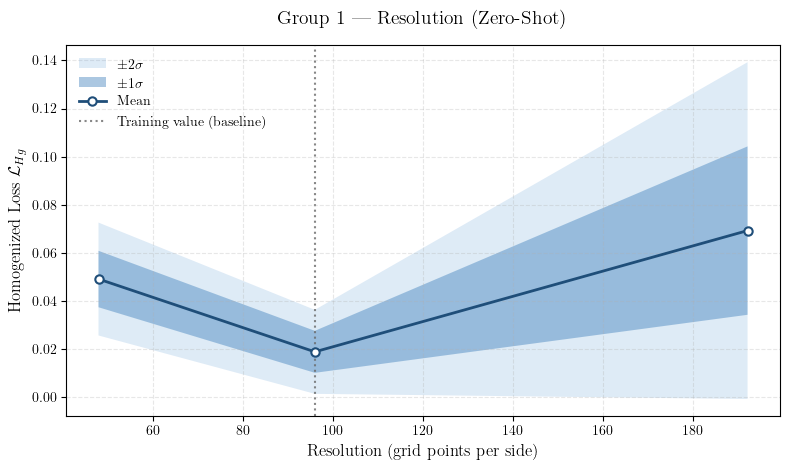

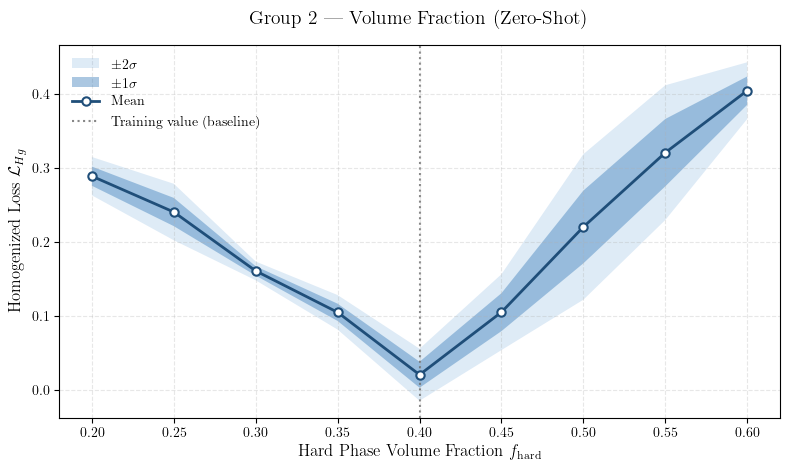

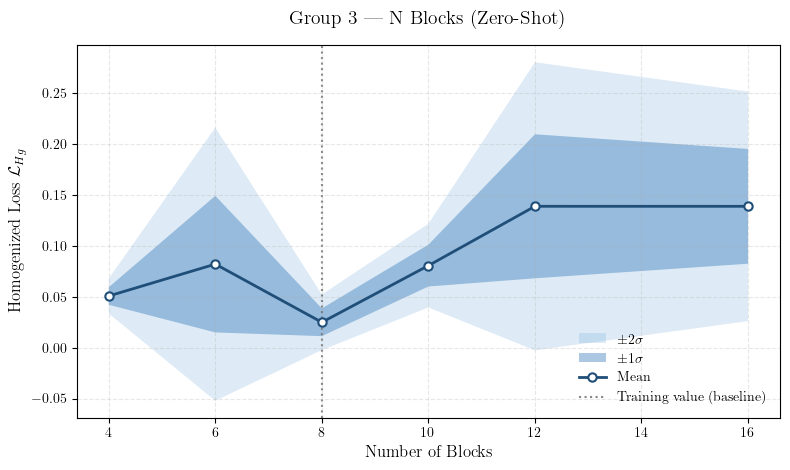

In [12]:

plt.rcParams.update({
    'font.family': 'serif',
    'text.usetex': True,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'xtick.labelsize': 10, 
    'ytick.labelsize': 10, 
    'axes.spines.top': True, 
    'axes.spines.right': True, 
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

for g_id, group in GROUPS.items():
    xp = group.get('x_param')
    if xp is None:
        continue

    sub  = df[df['group_id'] == g_id].sort_values(xp).reset_index(drop=True)
    x    = sub[xp].values.astype(float)
    bl   = group.get('baseline_cfg_idx')
    bl_x = sub.loc[sub['config_idx'] == bl, xp].values[0] if bl is not None else None

    means = sub['hg_mean'].values
    stds  = sub['hg_std'].values
    
    fig, ax = plt.subplots(figsize=(8, 4.8)) 
    
    ax.set_title(GROUP_TITLES[g_id], pad=15)

    ax.fill_between(x, means - 2*stds, means + 2*stds,
                    color=STYLE['col_band2'], alpha=0.20, edgecolor='none', label=r'$\pm 2\sigma$')
    ax.fill_between(x, means - stds, means + stds,
                    color=STYLE['col_band1'], alpha=0.40, edgecolor='none', label=r'$\pm 1\sigma$')
    

    ax.plot(x, means, marker='o', linestyle='-', color=STYLE['col_curve'], 
            lw=2, ms=6, markerfacecolor='white', markeredgewidth=1.5, zorder=4, label='Mean')

    # 4. LÍNEA BASE (BASELINE)
    if bl_x is not None:
        ax.axvline(bl_x, color='dimgray', ls=':', lw=1.5, alpha=0.8, zorder=1,
                   label='Training value (baseline)')

    ax.set_xlabel(AXIS_X_LABELS[xp])
    ax.set_ylabel(r'Homogenized Loss $\mathcal{L}_{Hg}$')
    
    ax.legend(loc='best', frameon=False)

    plt.tight_layout()
    
    plt.show()